# When research concepts were officially recognised: `data.py` demo

This notebook walks through **`data.py`**, the final step of the *external-recognition lookup table* artifact (outcome **O5**).
The artifact covers all **65,026 OpenAlex legacy concepts**. For each one it records dated, sourced events showing when an
outside body recognised the concept:

* **MeSH** `DateIntroduced` years,
* **English Wikipedia** page-creation dates (exact first revisions, or a calibrated page-id estimate),
* **Wikidata** P571/P575 inception and discovery dates,
* versioned taxonomies (**ACM CCS** 1998/2012, **MSC** 2000/2010/2020, **PACS 2010/PhySH**),
* curated "of the year" lists (Nature Methods MoTY, Science BOTY, Physics World BOTY, MIT TR10, Gartner Hype Cycle, Research Fronts).

Every event carries `year_usable`, `match_method`, `match_confidence` and `relation` (`same`/`narrower`/`broader`).

**What `data.py` does:** it converts the assembled concept rows (`work/concept_rows.pkl`) and the other pipeline intermediates
into the standard `exp_sel_data_out` JSON schema (`{"datasets": [{"dataset": ..., "examples": [{"input", "output", "metadata_*"}]}]}`).
It then checks the schema, splits the output into parts above 95 MB, and writes `mini_data_out.json` and `preview_data_out.json`.

**What this demo runs:** the upstream pipeline (steps s0-s8: OpenAlex S3, Wikipedia/Wikidata fetches, MeSH, LLM match
verification) takes hours and gigabytes, and its intermediates are not shipped. Instead, the notebook loads
`mini_demo_data.json`, a curated set of 100 published `concept_recognition` rows. It turns them back into the concept-row
frame `R`, then runs the **original `data.py` code path** on it: `build_datasets` → `check` → dataset/fold counts →
`full_data_out.json` + size-split rule → `mini_preview`.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install
_pip('loguru==0.7.3')

# pandas, pyarrow, numpy, matplotlib — pre-installed on Colab, install locally only (at Colab's versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'pyarrow==18.1.0', 'matplotlib==3.10.0')

## Imports

This is the original import block from `data.py`, plus the imports that `scripts/s9_outputs.py` needs (`ast`, `math`),
because the notebook defines its helpers inline. Two notebook-only changes:
* `ROOT = Path(__file__).resolve().parent` becomes a local output folder, because a notebook has no `__file__`.
* The `sys.path` hack and `from s9_outputs import ...` are removed, since those functions are copied into cells below.

`matplotlib` is added for the final visualisation.

In [2]:
from __future__ import annotations

import ast
import json
import math
import random
import sys
import time
from collections import Counter, defaultdict
from pathlib import Path

import pandas as pd  # noqa: E402
from loguru import logger  # noqa: E402
import matplotlib.pyplot as plt

# original: ROOT = Path(__file__).resolve().parent ; sys.path.insert(0, str(ROOT / "scripts"))
# original: from s9_outputs import build_datasets, trunc, write_parts   (defined inline below)
ROOT = Path("demo_outputs").resolve()          # everything data.py writes goes here
(ROOT / "logs").mkdir(parents=True, exist_ok=True)
WORK = ROOT / "work"   # pipeline intermediates (entries.parquet, links.parquet, ...) — not shipped with the demo
OUT = ROOT / "out"     # crosswalk_level1_to_field.csv, spotcheck_p78.csv — not shipped with the demo
print("output folder:", ROOT)

output folder: demo_outputs


## Load the demo data

`mini_demo_data.json` is fetched from the paper's GitHub repository, with a local copy as a fallback. It is an
`exp_sel_data_out` document holding one dataset, `concept_recognition`, with 100 rows:
* 10 known-answer / landmark concepts first (optogenetics, iPSC, CRISPR, super-resolution microscopy, genome editing, …);
* then a round-robin over the provisional hypothesis groups (BGM, CS, Eng, LifeEnv, MathDec, Med, Physical, Social, unassigned*),
  so any prefix of the list covers several groups;
* plus 2 level-0/1 ancestor rows.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8795ea-concepts-spread-once-adopters-make-them/fork/run_kLBLH5WmvR9Y/round-2/dataset-2/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print({d["dataset"]: len(d["examples"]) for d in data["datasets"]})

{'concept_recognition': 100}


## Configuration

These are all the tunable values. The originals are hard-coded in `data.py` / `s9_outputs.py`. The processing here is pure
Python over JSON and takes well under a second, so the demo uses **all 100 rows** in the mini file. The original values are
shown in the comments.

In [5]:
N_CONCEPTS = 100               # concept rows taken from mini_demo_data.json (original: all 65,026 rows of concept_rows.pkl)
LIMIT_BYTES = 95_000_000       # data.py: above this, full_data_out.json is split into parts (original: 95_000_000)
PART_BYTES = 90_000_000        # s9_outputs.py: max bytes per part (original: 90_000_000)
MINI_CAP = 200                 # rows per dataset in mini_data_out.json (original: 200)
PREVIEW_N = 10                 # rows per dataset in preview_data_out.json (original: 10)
TRUNC_N = 300                  # string truncation length in the preview (original: 300)
N_DATASETS_EXPECTED = 1        # datasets check() expects (original: 10; the demo rebuilds only concept_recognition)
SEED = 0                       # random.Random seed for the mini sample (original: 0)

## Rebuild the concept-row frame `R` (notebook-only adapter)

`data.py` starts with `R = pd.read_pickle(ROOT / "work" / "concept_rows.pkl")`, which gives one row per OpenAlex concept.
Each published `concept_recognition` example is a lossless serialisation of one such row:
* `input` holds the concept key: label, aliases, level, ancestors, `frame_role`, …
* `output` holds the recognition record: `events`, `sources_checked`, `present_day`.
* The `metadata_*` fields hold the fold, group and event counts.

This cell reverses that serialisation so the original code can run on the row subset unchanged.

In [6]:
_rows = []
for x in data["datasets"][0]["examples"][:N_CONCEPTS]:
    _rows.append({"openalex_id": x["metadata_openalex_id"], "input": json.loads(x["input"]), "output": json.loads(x["output"]),
                  "fold": x["metadata_fold"], "group": x["metadata_group"], "group_plurality": x["metadata_group_plurality"],
                  "group_plurality_share": x["metadata_group_plurality_share"], "level": x["metadata_level"],
                  "l1_fields": x["metadata_l1_fields"], "l0": x["metadata_level0"], "n_events": x["metadata_n_events"],
                  "n_events_year_usable": x["metadata_n_events_year_usable"]})
R_demo = pd.DataFrame(_rows)
R_demo[["openalex_id", "level", "group", "fold", "n_events", "n_events_year_usable"]].assign(
    label=[r["label"] for r in R_demo.input]).head(12)

,openalex_id,level,group,fold,n_events,n_events_year_usable,label
0,C50738837,2,LifeEnv,heldout,3,3,Optogenetics
1,C107459253,4,BGM,dev,4,4,Induced pluripotent stem cell
2,C98108389,3,BGM,dev,5,5,CRISPR
3,C166936260,4,Physical,heldout,3,2,Super-resolution microscopy
4,C144501496,4,BGM,dev,11,10,Genome editing
5,C108583219,2,CS,dev,8,8,Deep learning
6,C30080830,2,Physical,heldout,11,11,Graphene
7,C119857082,1,CS,dev,14,14,Machine learning
8,C128911142,2,Physical,heldout,5,4,Topological insulator
9,C109574028,2,Social,heldout,5,5,Behavioral economics


## Serialisation helpers (from `scripts/s9_outputs.py`)

* `clean` converts numpy scalars/arrays to plain Python and NaN/inf to `None`, so the JSON is strict.
* `dumps` is the strict JSON encoder used for every `input` and `output` string.
* `trunc` shortens long strings for the preview file.

These are copied unchanged; only `trunc`'s default length now uses the config value.

In [7]:
ACCEPT = {"same", "narrower_entry", "broader_entry"}


def clean(x):
    """Recursively convert numpy scalars/arrays to Python and NaN/inf to None (strict JSON)."""
    import math
    if isinstance(x, dict):
        return {str(k_): clean(v_) for k_, v_ in x.items()}
    if isinstance(x, (list, tuple)):
        return [clean(y) for y in x]
    if hasattr(x, "tolist") and not isinstance(x, (str, bytes)):
        return clean(x.tolist())
    if isinstance(x, float):
        return None if (math.isnan(x) or math.isinf(x)) else x
    return x


def dumps(x) -> str:
    return json.dumps(clean(x), ensure_ascii=False, allow_nan=False, default=str)


def trunc(x, n=TRUNC_N):
    if isinstance(x, str):
        return x if len(x) <= n else x[:n] + "..."
    if isinstance(x, list):
        return [trunc(y, n) for y in x]
    if isinstance(x, dict):
        return {k_: trunc(v_, n) for k_, v_ in x.items()}
    return x

## `build_datasets`: one example per data row (from `scripts/s9_outputs.py`)

The original function builds all **10 datasets**:
1. `concept_recognition`: one row per concept, built from `R` alone.
2. to 7. `external_entries_{mesh, acm_ccs, msc, pacs_physh, jel, curated_lists}`: one row per taxonomy node, MeSH
   descriptor or list item, with the concepts it matched. These need `entries.parquet`, `links.parquet`,
   `concept_keys.parquet`, `mesh_desc.parquet` and `list_entries.parquet`.
8. `match_verifications`: the 28,914 LLM judgements (`verifications.parquet`).
9. `crosswalk_level1_to_field` and 10. `spotcheck_p78` (CSV files in `out/`).

The function is copied **verbatim** below. Datasets 2 to 10 need pipeline intermediates that are not shipped, so the notebook
checks whether `work/entries.parquet` exists. If it does not, the notebook runs only dataset 1. `build_concept_recognition`
is the first block of `build_datasets`, copied unchanged.

In [8]:
def build_datasets(R: pd.DataFrame) -> list[dict]:
    e = pd.read_parquet(WORK / "entries.parquet").set_index("entry_id", drop=False)
    L = pd.read_parquet(WORK / "links.parquet")
    k = pd.read_parquet(WORK / "concept_keys.parquet").set_index("openalex_id")
    mesh = pd.read_parquet(WORK / "mesh_desc.parquet").set_index("mesh_ui")
    v = pd.read_parquet(WORK / "verifications.parquet")
    ds = []
    # 1 concept_recognition
    ex = []
    for r in R.itertuples(index=False):
        ex.append({"input": dumps(r.input), "output": dumps(r.output), "metadata_fold": r.fold, "metadata_group": r.group,
                   "metadata_group_plurality": r.group_plurality, "metadata_group_plurality_share": r.group_plurality_share,
                   "metadata_level": int(r.level), "metadata_l1_fields": [str(x) for x in r.l1_fields],
                   "metadata_level0": list(r.l0), "metadata_n_events": int(r.n_events),
                   "metadata_n_events_year_usable": int(r.n_events_year_usable),
                   "metadata_frame_role": r.input["frame_role"], "metadata_openalex_id": r.openalex_id,
                   "metadata_qid": r.input["qid"]})
    ds.append({"dataset": "concept_recognition", "examples": ex})
    # 2-7 external_recognition_entries, one dataset per source family
    Lg = {eid: g for eid, g in L.groupby("entry_id")}
    fam_name = {"mesh": "external_entries_mesh", "acm_ccs": "external_entries_acm_ccs", "msc": "external_entries_msc",
                "pacs_physh": "external_entries_pacs_physh", "jel": "external_entries_jel", "lists": "external_entries_curated_lists"}
    lst = pd.read_parquet(WORK / "list_entries.parquet").set_index("entry_id")
    for fam, name in fam_name.items():
        ex = []
        for r in e[e.family == fam].itertuples(index=False):
            g = Lg.get(r.entry_id)
            matched = [] if g is None else [
                {"openalex_id": x.openalex_id, "qid": k.at[x.openalex_id, "qid"], "label": k.at[x.openalex_id, "label"],
                 "relation": x.relation, "match_method": x.match_method, "match_confidence": round(float(x.match_confidence), 3),
                 "link_status": x.link_status} for x in g.itertuples(index=False)]
            as_int = lambda x: None if x is None or (isinstance(x, float) and x != x) else int(x)
            inp = {"entry_id": r.entry_id, "source": r.source, "version": as_int(r.version), "year": as_int(r.year), "code": r.code,
                   "label": r.label, "label_norm": r.label_norm, "alt_labels": list(r.alt_labels)[:20],
                   "descriptor": r.descriptor if isinstance(r.descriptor, str) else None, "generic_label": bool(r.generic)}
            if fam == "mesh" and r.source == "mesh":
                m = mesh.loc[r.code]
                inp.update({"date_introduced": m.date_introduced, "history_note": m.history_note,
                            "mesh_year_best": m.mesh_year_best, "mesh_year_rule": m.mesh_year_rule,
                            "mesh_baseline": bool(m.mesh_baseline), "tree_numbers": list(m.tree_numbers)[:12],
                            "top_branches": list(m.top_branches)})
            if fam == "lists":
                li = lst.loc[r.entry_id]
                inp.update({"role": li.role, "rank": None if pd.isna(li["rank"]) else int(li["rank"]), "phase": li.phase,
                            "wiki_links": list(li.wiki_links), "url": li.url, "primary_ref": li.primary_ref})
            ex.append({"input": dumps(inp), "output": dumps({"matched_concepts": matched, "n_matched": len(matched)}),
                       "metadata_source": r.source, "metadata_family": fam,
                       "metadata_year": None if r.year is None or pd.isna(r.year) else int(r.year),
                       "metadata_year_known": fam != "jel", "metadata_n_matched": len(matched),
                       "metadata_entry_id": r.entry_id})
        ds.append({"dataset": name, "examples": ex})
    # 8 match_verifications
    ex = []
    for r in v.itertuples(index=False):
        en = e.loc[r.entry_id] if r.entry_id in e.index else None
        ex.append({"input": dumps({"entry_id": r.entry_id, "entry_text": None if en is None else en.label,
                                   "entry_source": None if en is None else en.source,
                                   "candidate_openalex_id": r.openalex_id,
                                   "candidate_label": k.at[r.openalex_id, "label"] if r.openalex_id in k.index else None,
                                   "candidate_methods": list(r.methods)}),
                   "output": dumps({"relation": r.relation, "confidence": r.confidence, "accepted": r.relation in ACCEPT}),
                   "metadata_task": r.task, "metadata_model": r.model, "metadata_prompt_hash": r.prompt_hash,
                   "metadata_cost_usd": float(r.cost or 0.0), "metadata_status": r.status,
                   "metadata_family": None if en is None else en.family})
    ds.append({"dataset": "match_verifications", "examples": ex})
    # 9 crosswalk
    xw = pd.read_csv(OUT / "crosswalk_level1_to_field.csv")
    ds.append({"dataset": "crosswalk_level1_to_field", "examples": [
        {"input": dumps({"openalex_id": r.openalex_id, "display_name": r.display_name,
                         "level0_parents": ast.literal_eval(r.level0_parents) if isinstance(r.level0_parents, str) else []}),
         "output": dumps({"field_id": r.field_id, "field_name": r.field_name, "decided_by": r.decided_by, "reason": r.reason}),
         "metadata_model_a": str(r.model_a), "metadata_model_b": str(r.model_b), "metadata_decided_by": r.decided_by}
        for r in xw.itertuples(index=False)]})
    # 10 spot check
    sp = pd.read_csv(OUT / "spotcheck_p78.csv") if (OUT / "spotcheck_p78.csv").exists() else pd.DataFrame()
    if len(sp):
        ds.append({"dataset": "spotcheck_p78", "examples": [
            {"input": dumps({"concept": r.concept, "aliases_used": [a for a in str(r.aliases_used).split("|") if a and a != "nan"],
                             "t0": None if pd.isna(r.t0) else int(r.t0), "iter1_group": None if pd.isna(r.iter1_group) else r.iter1_group,
                             "iter1_home": None if pd.isna(r.iter1_home) else r.iter1_home}),
             "output": dumps({"joined": bool(r.joined), "openalex_id": None if pd.isna(r.openalex_id) else r.openalex_id,
                              "oa_label": None if pd.isna(r.oa_label) else r.oa_label,
                              "provisional_group": None if pd.isna(r.provisional_group) else r.provisional_group,
                              "events": [e for e in str(r.events).split("; ") if e and e != "nan"],
                              "sources_checked": json.loads(r.sources_checked) if isinstance(r.sources_checked, str) else None}),
             "metadata_joined": bool(r.joined), "metadata_iter1_status": r.iter1_status}
            for r in sp.itertuples(index=False)]})
    return ds


def build_concept_recognition(R: pd.DataFrame) -> list[dict]:
    """Demo-only: block '# 1 concept_recognition' of build_datasets, which needs nothing but R."""
    ds = []
    # 1 concept_recognition
    ex = []
    for r in R.itertuples(index=False):
        ex.append({"input": dumps(r.input), "output": dumps(r.output), "metadata_fold": r.fold, "metadata_group": r.group,
                   "metadata_group_plurality": r.group_plurality, "metadata_group_plurality_share": r.group_plurality_share,
                   "metadata_level": int(r.level), "metadata_l1_fields": [str(x) for x in r.l1_fields],
                   "metadata_level0": list(r.l0), "metadata_n_events": int(r.n_events),
                   "metadata_n_events_year_usable": int(r.n_events_year_usable),
                   "metadata_frame_role": r.input["frame_role"], "metadata_openalex_id": r.openalex_id,
                   "metadata_qid": r.input["qid"]})
    ds.append({"dataset": "concept_recognition", "examples": ex})
    return ds

## `write_parts`: the size rule (from `scripts/s9_outputs.py`)

If `full_data_out.json` is larger than `LIMIT_BYTES`, the datasets are packed greedily into `full_data_out/full_data_out_<n>.json`.
Each part is a valid `exp_sel_data_out` document of at most `PART_BYTES`, and a dataset may span two parts. In the real run,
the 65k concept rows and 94k entry and verification rows made three parts of about 90 MB. The 100 demo rows are far below
the limit, so this function is defined but not triggered.

In [9]:
def write_parts(ds: list[dict]) -> list[str]:
    d = ROOT / "full_data_out"
    d.mkdir(exist_ok=True)
    for f in d.glob("full_data_out_*.json"):
        f.unlink()
    parts, cur, cur_bytes = [], [], 0
    meta = {"description": "External, dated recognition events for OpenAlex legacy concepts (zero OpenAlex credits). "
                           "See README.md for field definitions, source biases and lags.",
            "parts_note": "Datasets are split across numbered parts; concatenate examples of equal 'dataset' names."}
    for d_ in ds:
        chunk = []
        for x in d_["examples"]:
            sz = len(dumps(x)) + 2
            if cur_bytes + sz > PART_BYTES and (chunk or cur):
                if chunk:
                    cur.append({"dataset": d_["dataset"], "examples": chunk})
                parts.append(cur)
                cur, chunk, cur_bytes = [], [], 0
            chunk.append(x)
            cur_bytes += sz
        if chunk:
            cur.append({"dataset": d_["dataset"], "examples": chunk})
    if cur:
        parts.append(cur)
    names = []
    for i, p in enumerate(parts, 1):
        f = d / f"full_data_out_{i}.json"
        f.write_text(json.dumps({"metadata": meta | {"part": i, "n_parts": len(parts)}, "datasets": p}, ensure_ascii=False))
        names.append(str(f.relative_to(ROOT)))
    return names

## `check` and `mini_preview` (from `data.py`)

`check` runs the schema rules that the JSON validator does not cover:
* dataset names are unique, and there are the expected number of them (10 originally, 1 here);
* every example has string `input`/`output`;
* all other keys start with `metadata_`, and no metadata value is a nested dict.

`mini_preview` writes the small companion files. For `concept_recognition`, it keeps only target concepts (level ≥ 2),
stratified by provisional group: per group, half the rows with the most events and half random (seed 0). The 200/10 caps
now come from the config cell; nothing else changed.

In [10]:
REQUIRED = ("input", "output")


def check(ds: list[dict]) -> None:
    """Schema-level checks the validator does not do: one example per row, string input/output, flat metadata."""
    names = [d["dataset"] for d in ds]
    assert len(names) == len(set(names)) == N_DATASETS_EXPECTED, names   # original: == 10
    for d in ds:
        assert d["examples"], d["dataset"]
        for x in d["examples"]:
            assert all(isinstance(x[k], str) for k in REQUIRED)
            bad = [k for k in x if k not in REQUIRED and not k.startswith("metadata_")]
            assert not bad, (d["dataset"], bad)
            assert not any(isinstance(v, dict) for k, v in x.items() if k.startswith("metadata_")), d["dataset"]


def mini_preview(ds: list[dict]) -> None:
    rnd = random.Random(SEED)
    mini, prev = [], []
    for d in ds:
        exs = d["examples"]
        if d["dataset"] == "concept_recognition":
            by = defaultdict(list)
            for x in exs:
                if x["metadata_level"] >= 2:
                    by[x["metadata_group"]].append(x)
            per = max(1, MINI_CAP // len(by))
            m = []
            for g in sorted(by):   # half the richest rows, half random, per provisional group
                m += sorted(by[g], key=lambda x: -x["metadata_n_events"])[:per // 2]
                m += rnd.sample(by[g], min(len(by[g]), per - per // 2))
            m = m[:MINI_CAP]
        else:
            m = exs if len(exs) <= MINI_CAP else rnd.sample(exs, MINI_CAP)
        mini.append({"dataset": d["dataset"], "examples": m})
        prev.append({"dataset": d["dataset"], "examples": trunc(m[:PREVIEW_N])})
    (ROOT / "mini_data_out.json").write_text(json.dumps({"datasets": mini}, ensure_ascii=False, indent=1))
    (ROOT / "preview_data_out.json").write_text(json.dumps({"datasets": prev}, ensure_ascii=False, indent=1))

## `main()` (from `data.py`)

This is the original driver. The only changes are:
* `R` is the frame rebuilt above instead of `pd.read_pickle(ROOT / "work" / "concept_rows.pkl")`.
* `build_datasets(R)` falls back to the concept-only block when the parquet intermediates are missing.

It logs the dataset sizes and fold counts, writes `full_data_out.json`, applies the 95 MB split rule and writes the
mini/preview files. All outputs go to `demo_outputs/`.

In [11]:
@logger.catch(reraise=True)
def main() -> list[dict]:
    logger.remove()
    logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
    logger.add(ROOT / "logs" / "data.log", rotation="30 MB", level="DEBUG")
    R = R_demo   # original: R = pd.read_pickle(ROOT / "work" / "concept_rows.pkl")
    logger.info(f"concept rows {len(R)}")
    ds = build_datasets(R) if (WORK / "entries.parquet").exists() else build_concept_recognition(R)  # original: build_datasets(R)
    check(ds)
    counts = {d["dataset"]: len(d["examples"]) for d in ds}
    logger.info(f"datasets: {counts}")
    fold = Counter(x["metadata_fold"] for x in ds[0]["examples"])
    logger.info(f"concept_recognition folds: {dict(fold)}")
    out = ROOT / "full_data_out.json"
    body = json.dumps({"metadata": {"description": "External, dated recognition events for OpenAlex legacy concepts",
                                    "n_examples": counts}, "datasets": ds}, ensure_ascii=False)
    out.write_text(body)
    size = out.stat().st_size
    logger.info(f"full_data_out.json {size / 1e6:.1f} MB")
    if size > LIMIT_BYTES:
        parts = write_parts(ds)
        out.unlink()
        logger.info(f"above {LIMIT_BYTES / 1e6:.0f} MB -> split into {parts}; single file removed")
    mini_preview(ds)
    logger.info("mini_data_out.json and preview_data_out.json written")
    return ds   # demo: return the datasets so the next cells can inspect them


_t0 = time.time()
ds = main()
print(f"data.py main() finished in {time.time() - _t0:.2f}s")

01:57:26|INFO   |concept rows 100


01:57:26|INFO   |datasets: {'concept_recognition': 100}


01:57:26|INFO   |concept_recognition folds: {'heldout': 42, 'dev': 42, 'unassigned': 16}


01:57:26|INFO   |full_data_out.json 0.6 MB


01:57:26|INFO   |mini_data_out.json and preview_data_out.json written


data.py main() finished in 0.17s


## Round-trip check

The rebuilt `concept_recognition` examples should match the published rows they came from **byte for byte**, because `R` was
reconstructed from them and serialised again with the same `dumps`. Matching rows show that the serialisation is lossless and
that the notebook runs the same code path as the artifact.

Note: `mini_data_out.json` can come out *larger* than `full_data_out.json` here. With only about 10 rows per group, the "richest half" and the "random half" of `mini_preview` overlap, so rows are repeated, and the file is also indented. On the real 65k rows, the mini file is a small stratified sample.

In [12]:
orig = data["datasets"][0]["examples"][:N_CONCEPTS]
rebuilt = ds[0]["examples"]
n_same = sum(a == b for a, b in zip(orig, rebuilt))
print(f"identical rows: {n_same}/{len(rebuilt)}")
for f in ["full_data_out.json", "mini_data_out.json", "preview_data_out.json"]:
    p = ROOT / f
    print(f"{f:24s} {p.stat().st_size / 1e3:8.1f} KB")

identical rows: 100/100
full_data_out.json          602.7 KB
mini_data_out.json         1150.4 KB
preview_data_out.json        12.2 KB


## Results: what the recognition table looks like

The cells below unpack the `output` field of every rebuilt row:
1. **Known-answer concepts**: the dated events for the landmark concepts. The artifact's QC asserts optogenetics = NM Method
   of the Year 2010, iPSC = NM 2009, CRISPR = Science Breakthrough of the Year 2015, super-resolution = NM 2008.
2. **Coverage by source**: how often each source was `found`, `not_found` or `not_applicable` among the demo concepts.
3. **Event years by source**: when year-usable events fall. Note the Wikipedia 2001-2007 growth wave and the MeSH/taxonomy
   baseline years.

*Caveat:* the demo rows are a curated, event-rich sample (landmark concepts plus the richest rows per group). The coverage shares and events per group below therefore overstate the full table. Use `out/coverage_report.json` of the artifact for population numbers.

In [13]:
rows = []
for x in ds[0]["examples"]:
    i, o = json.loads(x["input"]), json.loads(x["output"])
    rows.append({"label": i["label"], "level": i["level"], "group": x["metadata_group"], "fold": x["metadata_fold"],
                 "events": o["events"], "sources_checked": o["sources_checked"], "present_day": o["present_day"]})

# 1) known-answer / landmark concepts: first year-usable event per source
KNOWN = {"Optogenetics", "Induced pluripotent stem cell", "CRISPR", "Super-resolution microscopy", "Genome editing",
         "Deep learning", "Graphene", "Machine learning", "Topological insulator", "Behavioral economics"}
tab = []
for r in rows:
    if r["label"] in KNOWN:
        first = {}
        for e in sorted(r["events"], key=lambda e: (e["year"] or 9999)):
            if e["year_usable"] and e["year"] is not None and e["source"] not in first:
                first[e["source"]] = f'{e["year"]}' + ("" if e["relation"] == "same" else f' ({e["relation"]})')
        tab.append({"concept": r["label"], "group": r["group"], **first})
known_df = pd.DataFrame(tab).set_index("concept").fillna("")
pd.set_option("display.width", 250); pd.set_option("display.max_columns", 30)
print("First year-usable recognition event per source (relation shown when not 'same'):")
display(known_df)

# the curated-list events that the artifact's QC asserts check
print("\nCurated-list events for the QC concepts:")
for r in rows:
    if r["label"] in {"Optogenetics", "Induced pluripotent stem cell", "CRISPR", "Super-resolution microscopy"}:
        ev = [f'{e["year"]} {e["event_type"]} ({e["relation"]})' for e in r["events"]
              if e["source"] in {"nature_methods_moty", "science_boty"}]
        print(f'  {r["label"]:32s}', "; ".join(ev))

First year-usable recognition event per source (relation shown when not 'same'):


,group,wikipedia_en,nature_methods_moty,mesh,science_boty,wikidata,mit_tr10,physics_world_boty,research_fronts,pacs_physh,gartner_hype_cycle,acm_ccs
concept,,,,,,,,,,,,
Optogenetics,LifeEnv,2007,2010,2013,,,,,,,,
Induced pluripotent stem cell,BGM,2007,2009,2010,2008 (narrower),,,,,,,
CRISPR,BGM,2005,,2014,2015 (narrower),1987,2023 (narrower),,,,,
Super-resolution microscopy,Physical,,2008,,,,,2017,,,,
Genome editing,BGM,,2011 (broader),2017,2015 (narrower),,2014,,2017 (narrower),,,
Deep learning,CS,2011,,2019,,,2013,,,2016,2017,
Graphene,Physical,2004,,,,2004,2008 (broader),2013 (narrower),2020 (narrower),2010,,
Machine learning,CS,2003,,2016,,,2004 (broader),,,2016,2015,2012
Topological insulator,Physical,,,,,,,,2020 (narrower),2016,,



Curated-list events for the QC concepts:
  Optogenetics                     2010 nature_methods_method_of_the_year (same)
  Induced pluripotent stem cell    2008 science_breakthrough_of_the_year (narrower); 2009 nature_methods_method_of_the_year (same)
  CRISPR                           2015 science_breakthrough_of_the_year (narrower)
  Super-resolution microscopy      2008 nature_methods_method_of_the_year (same)


sources_checked status counts across 100 demo concepts:


,found,found_estimated,not_found,not_applicable
wikidata,10,0,90,0
wikipedia_en,23,77,0,0
mesh,61,0,16,23
acm_ccs,23,0,6,71
msc,13,0,5,82
pacs_physh,23,0,10,67
jel,0,0,4,96
nature_methods_moty,5,0,48,47
science_boty,6,0,94,0
physics_world_boty,6,0,12,82



632 year-usable events; relation mix: {'same': 368, 'narrower': 159, 'broader': 105}


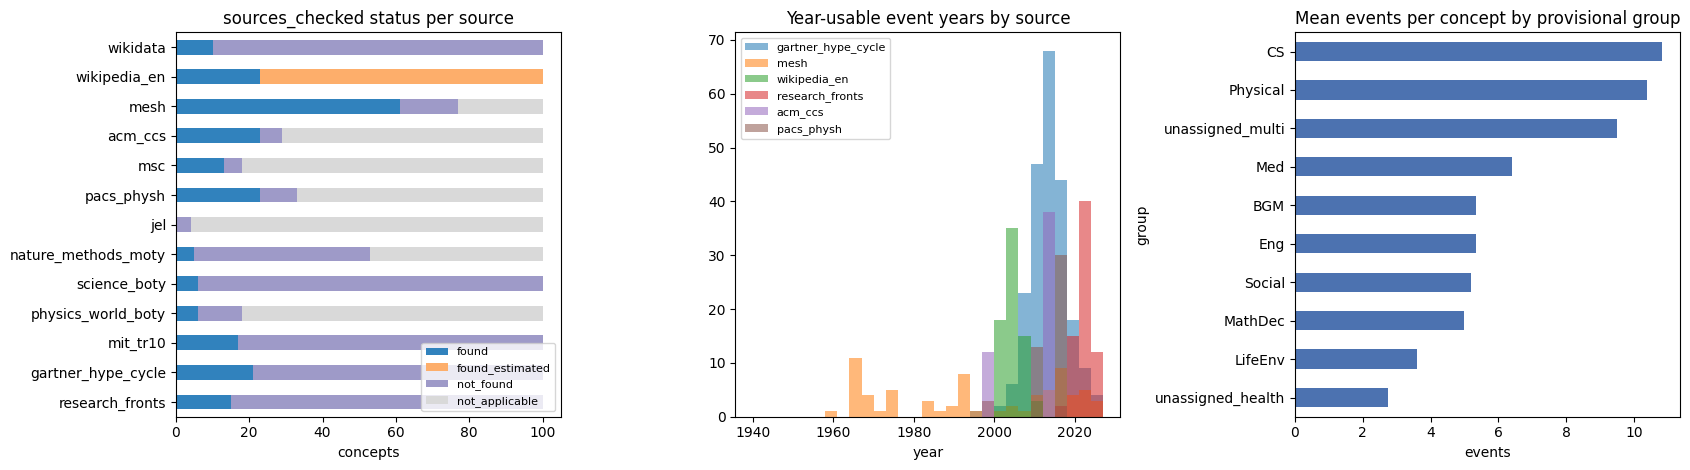

In [14]:
# 2) coverage by source (status counts over the demo concepts)
cov = pd.DataFrame([r["sources_checked"] for r in rows]).apply(lambda c: c.value_counts()).fillna(0).astype(int).T
cov = cov.reindex(columns=[c for c in ["found", "found_estimated", "not_found", "not_applicable"] if c in cov.columns]
                  + [c for c in cov.columns if c not in {"found", "found_estimated", "not_found", "not_applicable"}])
print("sources_checked status counts across", len(rows), "demo concepts:")
display(cov)

# 3) year-usable events by source
ev = pd.DataFrame([{"source": e["source"], "year": e["year"], "relation": e["relation"], "match_method": e["match_method"]}
                   for r in rows for e in r["events"] if e["year_usable"] and e["year"] is not None])
print(f"\n{len(ev)} year-usable events;", "relation mix:", dict(Counter(ev.relation)))

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
cov.plot.barh(stacked=True, ax=axes[0], colormap="tab20c")
axes[0].set_title("sources_checked status per source"); axes[0].set_xlabel("concepts"); axes[0].invert_yaxis()
axes[0].legend(fontsize=8)

top = ev.source.value_counts().index[:6]
for s in top:
    axes[1].hist(ev[ev.source == s].year, bins=range(1940, 2030, 3), alpha=0.55, label=s)
axes[1].set_title("Year-usable event years by source"); axes[1].set_xlabel("year"); axes[1].legend(fontsize=8)

ne = pd.DataFrame([{"group": r["group"], "n": len(r["events"])} for r in rows])
ne.groupby("group").n.mean().sort_values().plot.barh(ax=axes[2], color="#4c72b0")
axes[2].set_title("Mean events per concept by provisional group"); axes[2].set_xlabel("events")
plt.tight_layout(); plt.show()

## Scaling back to the full run

To reproduce the real deliverable, clone the artifact and run `./restore.sh && ./run_all.sh`, or run only the final step,
`uv run data.py`, with the pipeline intermediates in `work/` and `out/`. That uses all 65,026 concept rows and all 10 datasets.
In the notebook, set `N_DATASETS_EXPECTED = 10` and place the intermediates under `demo_outputs/work` and `demo_outputs/out`.
The verbatim `build_datasets` then takes over automatically, and `write_parts` splits the ~257 MB output into three
parts of about 90 MB.